## setup

In [ ]:
#install kaggle

!pip install kaggle

In [ ]:
#import library

import os #file operation
import zipfile as zip #to unzip datasets
import pandas as pd #data manipulation
import numpy as np #numeric operation
import matplotlib.pyplot as plt #data visualization
import joblib as jb #model
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from google.colab import files #upload kaggle.json

In [ ]:
uploaded=files.upload() #file picker

#create hidden kaggle directory if it doesnt exist
os.makedirs('/root/.kaggle', exist_ok=True)

#move kaggle.json
if 'kaggle.json' in uploaded:
  with open('/root/.kaggle/kaggle.json', 'wb') as f:
    f.write(uploaded['kaggle.json'])
  os.chmod('/root/.kaggle/kaggle.json', 0o600) #set permision to owner only
else:
  raise FileNotFoundError('kaggle.json not found')

Saving kaggle.json to kaggle.json


In [ ]:
#download dataset from kaggle CLI

!kaggle datasets download -d uciml/pima-indians-diabetes-database -p /content

Dataset URL: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
License(s): CC0-1.0
  0% 0.00/8.91k [00:00<?, ?B/s]
100% 8.91k/8.91k [00:00<00:00, 37.0MB/s]


## load data

In [ ]:
#unzip the datasets

with zip.ZipFile('/content/pima-indians-diabetes-database.zip', 'r') as z:
  z.extractall('/content/diabetes')

In [ ]:
#list extract data

import glob as g

g.glob('/content/diabetes/*',recursive=True)[:1]

['/content/diabetes/diabetes.csv']

In [ ]:
#load the csv

csv_path='/content/diabetes/diabetes.csv'

#if not found data name

if not os.path.exists(csv_path):
  csv_candidate=g.glob('/content/diabetes/*',recursive=True)
  if len(csv_candidate)==0:
    raise FileNotFoundError(f'Data not found at {csv_path}')
  csv_path=csv_candidate[0]

df=pd.read_csv(csv_path)
print("loaded: ", csv_path)
print("shape: ", df.shape)
df.head()

loaded:  /content/diabetes/diabetes.csv
shape:  (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## data structure

In [ ]:
#info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
#describe

df.describe(include='all')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## handle missing value

In [ ]:
#before handling
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
#fill numerical colom missing value with median

num_cols=df.select_dtypes(include=['int64','float64']).columns.tolist() #convert to array

for c in num_cols:
  df[c]=df[c].fillna(df[c].median())

In [ ]:
#fill categorical colom with uknown

cat_cols=df.select_dtypes(include=['object']).columns.tolist() #convert to array
for c in cat_cols:
  mode_val=df[c].mode()
  mode_val=mode_val.iloc[0] if not mode_val.empty else 'unknown'
  df[c]=df[c].fillna(mode_val)

In [ ]:
#after handling
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


## outliers

In [ ]:
#clean data outliers

def clean_outliers(df,col):
  q1,q3=np.percentile(df[col].dropna(),[25,75]) #compute q1(25) q3(75)

    #iqr
  iqr=q3-q1

    #lower and upper bound
  lower_bound=q1-1.5*iqr
  upper_bound=q3+1.5*iqr


  outliers=df[(df[col]<lower_bound) | (df[col]>upper_bound)]
  print(f'column {col} has {len(outliers)} outliers')
  print('lower bound: ',lower_bound)
  print('upper bound: ',upper_bound)
  cap_outliers(df,col,lower_bound,upper_bound)

In [ ]:
def plot_outliers(df_before,df_after,col):
  plt.figure(figsize=(12,4))

  #before cap
  plt.subplot(1,2,1)
  plt.hist(df_before[col].dropna(), bins=40)
  plt.title(f'Before cap of {col}')
  plt.xlabel(col)
  plt.ylabel('Frequency')


  #after cap
  plt.subplot(1,2,2)
  plt.hist(df_after[col].dropna(), bins=40)
  plt.title(f'After cap of {col}')
  plt.xlabel(col)
  plt.ylabel('Frequency')

  plt.show()

In [ ]:
#cap

def cap_outliers(df,col,lower_bound,upper_bound):
  df_cap=df.copy()
  df_cap[col]=np.clip(df_cap[col],lower_bound,upper_bound)
  plot_outliers(df,df_cap,col)

## cap plot pregnancies

column Pregnancies has 4 outliers
lower bound:  -6.5
upper bound:  13.5


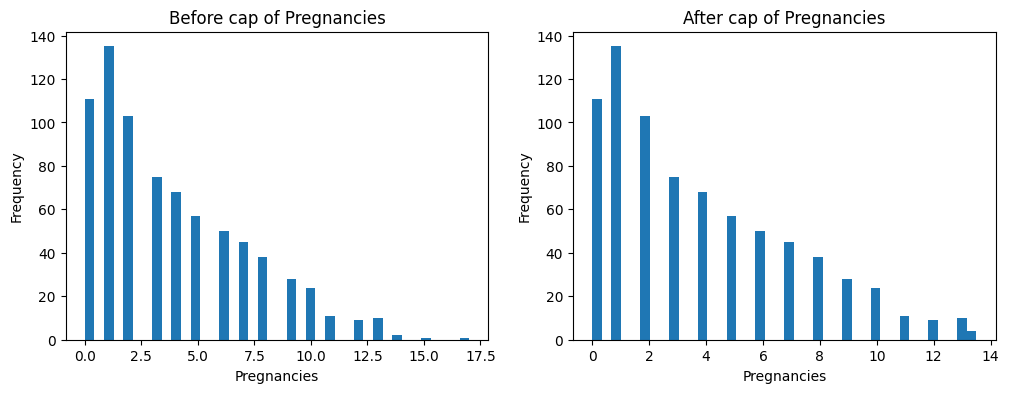

In [ ]:
clean_outliers(df,'Pregnancies')

## cap plot glucose

column Glucose has 5 outliers
lower bound:  37.125
upper bound:  202.125


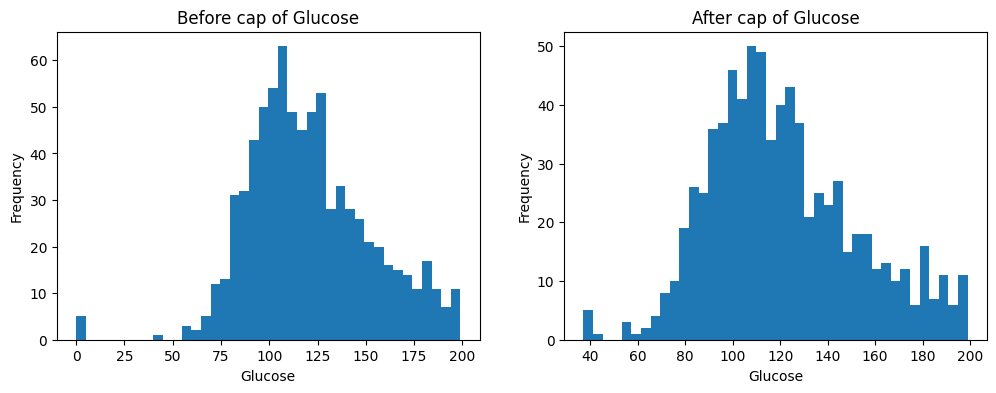

In [ ]:
clean_outliers(df,'Glucose')

## cap plot bloodpressure

column BloodPressure has 45 outliers
lower bound:  35.0
upper bound:  107.0


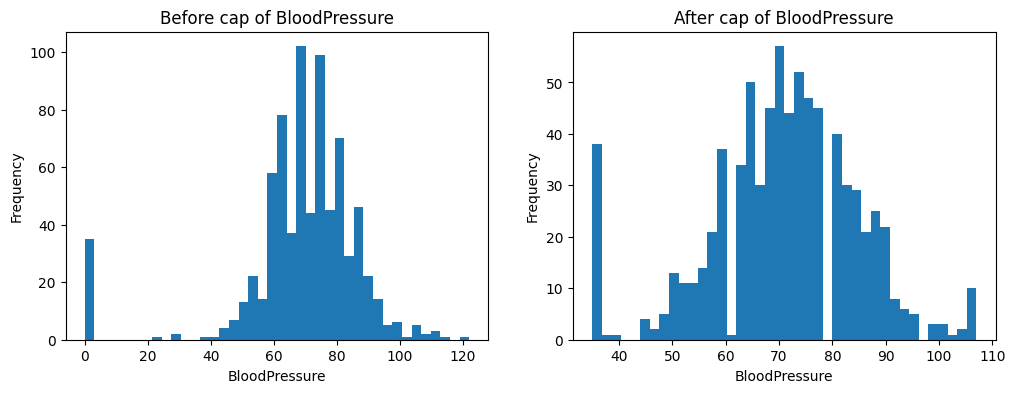

In [ ]:
clean_outliers(df,'BloodPressure')

## cap plot insulin

column Insulin has 34 outliers
lower bound:  -190.875
upper bound:  318.125


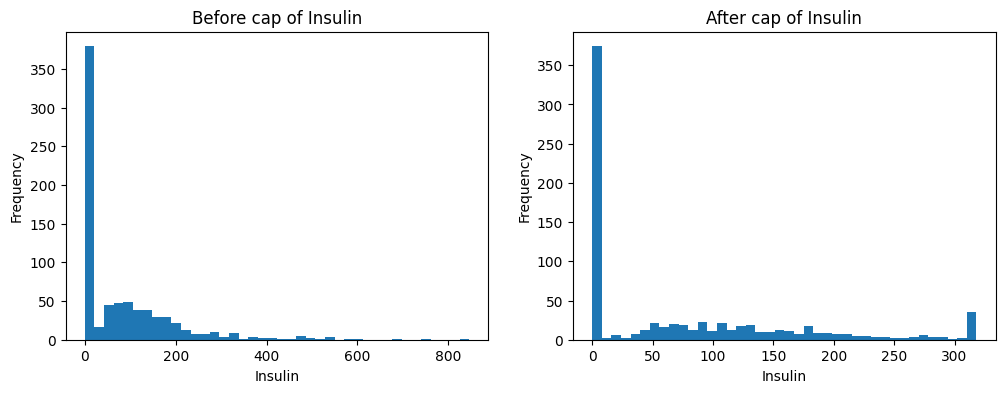

In [ ]:
clean_outliers(df,'Insulin')

## cap plot bmi

column BMI has 19 outliers
lower bound:  13.35
upper bound:  50.550000000000004


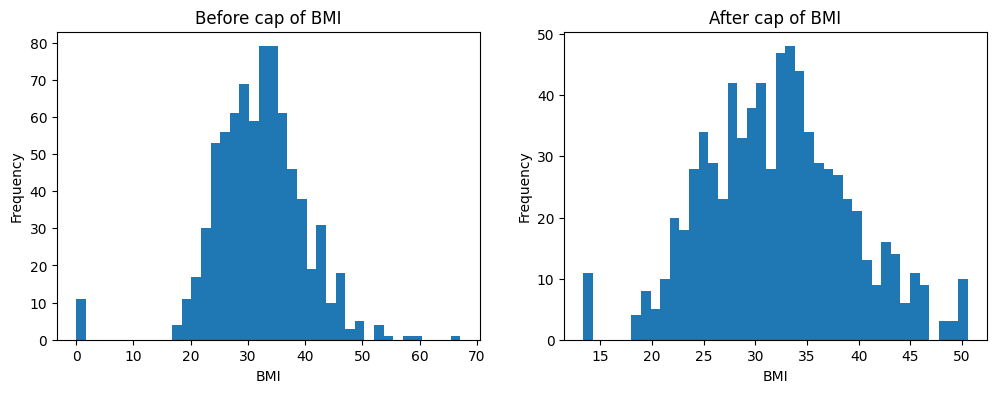

In [ ]:
clean_outliers(df,'BMI')

## cap plot diabetes pedigree function

column DiabetesPedigreeFunction has 29 outliers
lower bound:  -0.32999999999999996
upper bound:  1.2


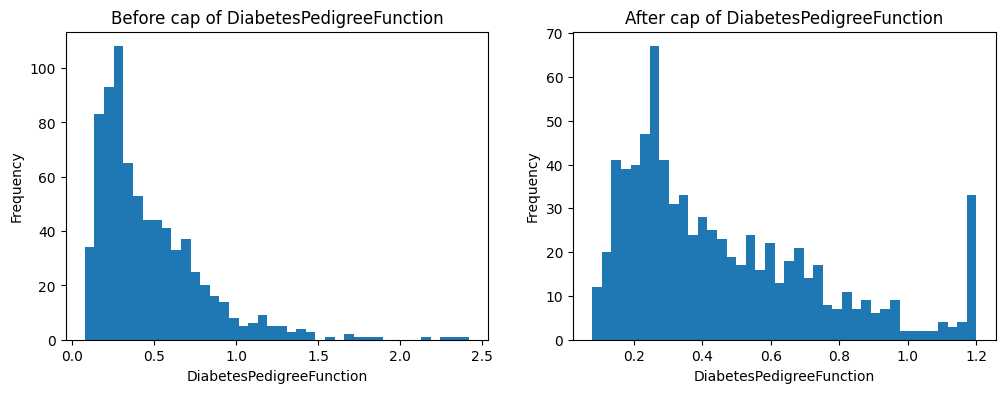

In [ ]:
clean_outliers(df,'DiabetesPedigreeFunction')

## cap plot age

column Age has 9 outliers
lower bound:  -1.5
upper bound:  66.5


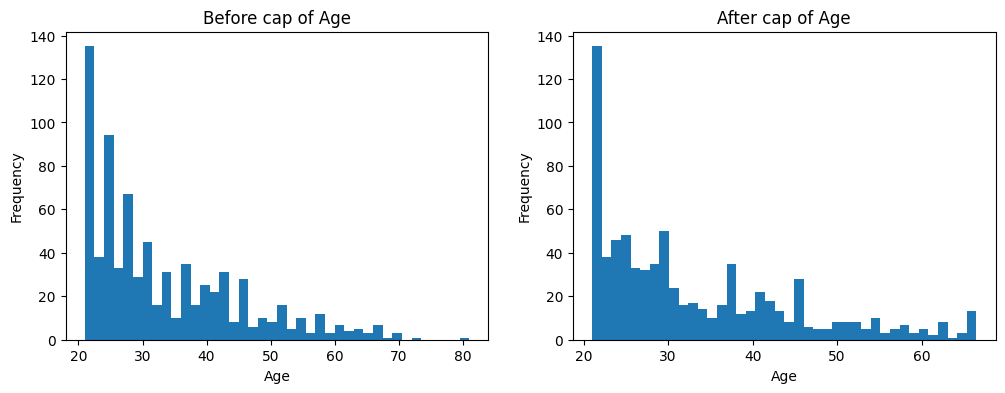

In [ ]:
clean_outliers(df,'Age')

## scalling

In [ ]:
scale_col=[c for c in df.columns if c!='Outcome']
scaler=MinMaxScaler()
df_scale=df.copy()
if scale_col:
  df_scale[scale_col]=scaler.fit_transform(df[scale_col])
  print(df_scale[scale_col].head())
else:
  print('no column to scale')

   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0     0.352941  0.743719       0.590164       0.353535  0.000000  0.500745   
1     0.058824  0.427136       0.540984       0.292929  0.000000  0.396423   
2     0.470588  0.919598       0.524590       0.000000  0.000000  0.347243   
3     0.058824  0.447236       0.540984       0.232323  0.111111  0.418778   
4     0.000000  0.688442       0.327869       0.353535  0.198582  0.642325   

   DiabetesPedigreeFunction       Age  
0                  0.234415  0.483333  
1                  0.116567  0.166667  
2                  0.253629  0.183333  
3                  0.038002  0.000000  
4                  0.943638  0.200000  


## data split

In [ ]:
def split_frame(frame,train_ratio=0.8):
  split=int(len(frame)*train_ratio) #80% dari data untuk training sisanya untuk test

  x=frame.drop(columns=['Outcome']).values #feature
  y=frame['Outcome'].values.astype(int) #label

  X_train=x[:split]
  X_test=x[split:]
  y_train=y[:split]
  y_test=y[split:]

  return X_train,X_test,y_train,y_test,split

In [ ]:
#treshold untuk menentukan label

def treshold(model,X_train,y_train,tail_ratio=0.2):
  val=max(50, int(tail_ratio*len(X_train)))
  X_train,X_val=X_train[:-val],X_train[-val:]
  y_train,y_val=y_train[:-val],y_train[-val:]
  model.fit(X_train,y_train)

  val_proba=model.predict_proba(X_val)[:,1]
  thr=np.linspace(0.2,0.8, 61)
  best_thr,best_f1=0.5,-1

  for t in thr: #loopingan mencari best thr dan best f1
    y_pred=(val_proba>= t).astype(int)
    f1=f1_score(y_val,y_pred,zero_division=0)
    if f1>best_f1:
      best_f1=f1
      best_thr=t
  return best_thr,best_f1

In [ ]:
#splitting

X_train,X_test,y_train,y_test,split=split_frame(df_scale)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


## model logreg

In [ ]:
#build pipeline

logreg=Pipeline([
    ('scaler',StandardScaler()),
    ('model',LogisticRegression(
        solver='liblinear',
        class_weight='balanced',
        C=1.0,
        random_state=42
    ))
])

#treshold tuning validation

best_thr,best_f1=treshold(logreg,X_train,y_train)
best_thr+=0
print(f'best threshold: {best_thr}')
print(f'best f1 score: {best_f1}')

logreg.fit(X_train,y_train)

best threshold: 0.53
best f1 score: 0.7671232876712328


Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', random_state=42,
                                    solver='liblinear'))])

## evaluate

Confusion matrix:
 [[81 18]
 [19 36]]
Accuracy:  0.7597
Classification report:
               precision    recall  f1-score   support

           0     0.8100    0.8182    0.8141        99
           1     0.6667    0.6545    0.6606        55

    accuracy                         0.7597       154
   macro avg     0.7383    0.7364    0.7373       154
weighted avg     0.7588    0.7597    0.7592       154



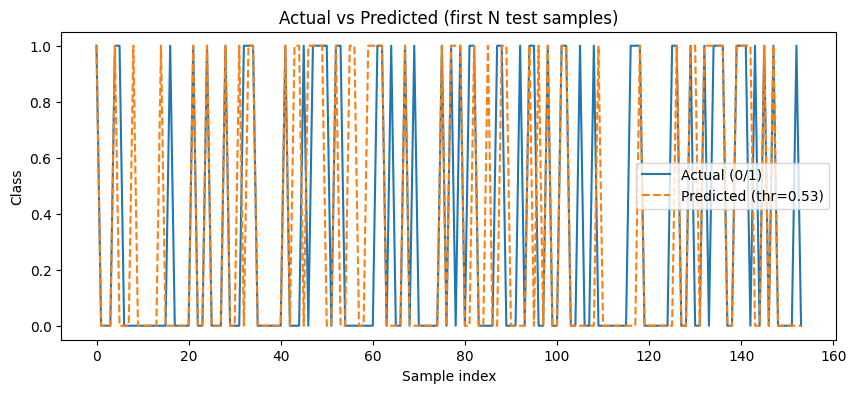

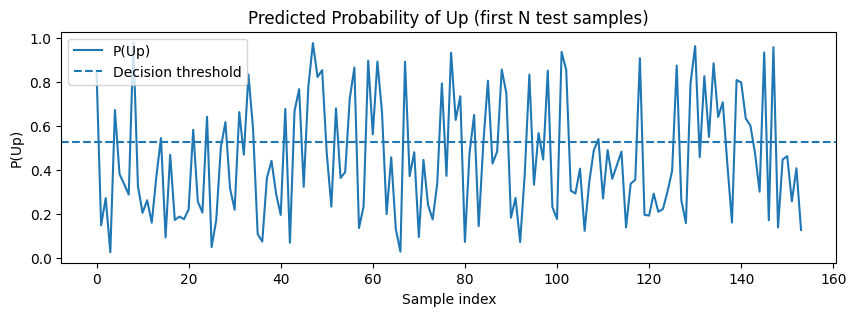

In [ ]:
#predict proba
test_proba=logreg.predict_proba(X_test)[:,1]
y_pred_thr=(test_proba>=best_thr).astype(int)

#metrics
print('Confusion matrix:\n',confusion_matrix(y_test,y_pred_thr))
print('Accuracy: ',round(accuracy_score(y_test,y_pred_thr),4))
print('Classification report:\n',classification_report(y_test,y_pred_thr,digits=4))

#plot
N = min(200, len(y_test))
plt.figure(figsize=(10,4))
plt.plot(range(N), y_test[:N], label='Actual (0/1)')
plt.plot(range(N), y_pred_thr[:N], label=f'Predicted (thr={best_thr:.2f})', linestyle='--')
plt.title('Actual vs Predicted (first N test samples)')
plt.xlabel('Sample index'); plt.ylabel('Class')
plt.legend(); plt.show()

plt.figure(figsize=(10,3))
plt.plot(range(N), test_proba[:N], label='P(Up)')
plt.axhline(best_thr, linestyle='--', label='Decision threshold')
plt.title('Predicted Probability of Up (first N test samples)')
plt.xlabel('Sample index'); plt.ylabel('P(Up)')
plt.legend(); plt.show()

## export and load model

In [ ]:
#export model
jb.dump(logreg,'logreg.pkl')

#load model
loaded_model = jb.load('logreg.pkl')
print('Loaded model from : logreg.pkl')
print('type model : ', type(loaded_model))

Loaded model from : logreg.pkl
type model :  <class 'sklearn.pipeline.Pipeline'>


In [ ]:
#check
sample_X = [[0.352941,0.743719, 0.590164,0.353535,0.000000,0.500745,0.234415,0.483333]] #feature(datasets paling atas)
print('Sample prediction:', loaded_model.predict(sample_X)) #output class : 0 OR 1
print('Probability P(Up)', loaded_model.predict_proba(sample_X)[0][1]) # output probability

Sample prediction: [1]
Probability P(Up) 0.8015346747141722


In [ ]:
#install
!pip install streamlit numpy matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 81.1 MB/s eta 0:00:00


## run streamlit

In [ ]:
# Install runtime deps
!pip -q install streamlit joblib numpy matplotlib scikit-learn

# Get cloudflared (no login needed for quick tunnels)
!wget -q -O /content/cloudflared https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x /content/cloudflared

import subprocess, time, re, sys

# Start Streamlit in background
streamlit_cmd = ["streamlit", "run", "app.py", "--server.port", "8501", "--server.address", "0.0.0.0"]
streamlit_log = open("/content/streamlit.log", "w")
streamlit_proc = subprocess.Popen(streamlit_cmd, stdout=streamlit_log, stderr=streamlit_log, text=True)

time.sleep(3)  # let streamlit start

# Start cloudflared and parse URL
cloudflared_cmd = ["/content/cloudflared", "tunnel", "--url", "http://localhost:8501", "--no-autoupdate"]
cloudflared_proc = subprocess.Popen(cloudflared_cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)

public_url = None
start = time.time()
while time.time() - start < 60:
    line = cloudflared_proc.stdout.readline()
    if not line:
        time.sleep(0.2)
        continue
    sys.stdout.write(line)
    sys.stdout.flush()
    m = re.search(r"(https://[-a-zA-Z0-9.]*trycloudflare.com)", line)
    if m:
        public_url = m.group(1)
        break

if public_url:
    print("\n✅ External URL:", public_url)
    print("Share this link. Re-run this cell to refresh if it stops responding.")
else:
    print("\n⚠️ Could not detect the public URL. Scroll logs above for a trycloudflare.com link or rerun the cell.")

2026-03-14T06:57:33Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-03-14T06:57:33Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-03-14T06:57:41Z INF +--------------------------------------------------------------------------------------------+
2026-03-14T06:57:41Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-03-14T06:57:41Z INF |  https://games-english-patients-heat.trycloudflare.com

In [ ]:
!streamlit run app.py

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py
